# Example code : using multi layer perceptron

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Datasets/Churn_rate_prediction.csv")

In [3]:
print(df.isna().sum().sum())
print()
print(df.shape)
print()
df.isna().sum()

0

(10000, 14)



RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df.sample(6)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8982,8983,15627971,Coates,504,France,Female,32,8,206663.75,1,0,0,16281.94,0
5943,5944,15658813,Siciliani,645,France,Female,55,7,0.00,2,1,1,18369.33,0
7734,7735,15722473,Faulkner,713,France,Male,41,3,0.00,2,1,0,55772.04,0
8314,8315,15734177,Donahue,643,France,Male,33,4,0.00,2,1,1,152992.04,0
3088,3089,15730448,Iroawuchi,538,Germany,Male,25,5,62482.95,1,1,1,102758.43,0
6421,6422,15579994,Shaw,616,France,Male,23,8,73112.95,1,1,1,62733.05,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
df.duplicated(subset='CustomerId').sum()        # checkig for duplicated based on customer id

np.int64(0)

In [8]:
df = df.drop(columns='Surname')

In [9]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
df.select_dtypes(include='str').columns

Index(['Geography', 'Gender'], dtype='str')

In [12]:
# using OHE via 'get_dummies'

df = pd.get_dummies(df, columns=df.select_dtypes(include='str').columns, drop_first=True)

In [13]:
df.sample(10)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
6047,6048,15790247,536,40,9,0.00,2,1,1,11959.03,0,False,True,True
4718,4719,15675787,505,26,8,112972.57,1,1,0,145011.62,0,False,False,True
2599,2600,15704844,550,62,7,80927.56,1,0,1,64490.67,0,False,True,True
1858,1859,15780746,705,61,4,0.00,2,1,1,191313.70,0,False,False,True
8021,8022,15697691,512,41,6,0.00,1,1,1,100507.81,0,False,False,False
1506,1507,15599956,747,27,10,0.00,2,0,0,13007.89,0,False,False,True
4256,4257,15578462,596,76,9,134208.25,1,1,1,13455.43,0,False,True,False
1758,1759,15645544,642,30,5,129753.69,1,1,0,582.53,0,True,False,False
7314,7315,15686670,588,36,2,0.00,2,1,0,92536.00,1,False,False,False
9176,9177,15610433,573,35,9,0.00,2,1,0,11743.89,0,False,False,True


In [14]:
x = df.drop(columns=['RowNumber', 'CustomerId', 'Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [18]:
model = Sequential()

In [19]:
x_train.shape

(7000, 11)

This code defines the architecture of the Neural Network using Keras. It is building the "layers" of the perceptron with mentioned neurons one by one.

In [20]:
model.add(Dense(3, activation='sigmoid', input_dim=11))                         # first hidden layer with 3 neurons
# 3 -- a layer with 3 neurons
# input_dim=11 -- tells the model that the dataset has 11 input features
# activation='sigmoid' -- tells the model to use sigmoid function


model.add(Dense(2, activation='sigmoid'))                                       # second hidden layer with 2 neuron
model.add(Dense(1, activation='sigmoid'))                                       # third hidden layer with 1 neuron





d:\THE CODE\Deep_Learning\DL\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()               # gives a summary of the model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47 (188.00 B)

 Trainable params: 47 (188.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Summary Breakdown (sequential_4)

| Layer | Output Shape | Param # | Calculation Logic |
| :--- | :--- | :--- | :--- |
| **dense_18** | (None, 3) | **36** | (11 Inputs * 3 Neurons) + 3 Biases |
| **dense_19** | (None, 2) | **8** | (3 Inputs * 2 Neurons) + 2 Biases |
| **dense_20** | (None, 1) | **3** | (2 Inputs * 1 Neuron) + 1 Bias |

---

### Total Knowledge of the Model
*   **Total Parameters: 47** 
*   This model is smaller and more efficient than your previous one (which had 59 params).
*   It compresses the **11 original features** into a final **single answer** using 47 mathematical "knobs."

### Data Flow Visualization:
**11 Features** $\rightarrow$ **3 Neurons** $\rightarrow$ **2 Neurons** $\rightarrow$ **1 Final Prediction**


In [ ]:
# in this you put the loss functions and various other parameters to be used in the model

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

# optimizer='Adam' -- The optimizer is the algorithm that updates the weights to reduce the error.
# loss='binary_crossentropy' -- The loss function is how the model calculates how wrong it is.
# metrics=['accuracy'] -- While the model uses "Loss" to learn, we humans prefer to see "Accuracy."

## Keras Compile Parameters: The Alternatives

Depending on your data and your goal, you may need to swap out `Adam`, `binary_crossentropy`, or `accuracy`.



### 1. Optimizers (The "How to learn")
The Optimizer determines how the weights are updated.

| Parameter | Name | When to use it |
| :--- | :--- | :--- |
| `'adam'` | Adam | The "Gold Standard." Use this 90% of the time. |
| `'sgd'` | Stochastic Gradient Descent | Classic and stable. Good for very deep networks or specific fine-tuning. |
| `'rmsprop'` | RMSprop | Often used in Recurrent Neural Networks (RNNs) for text or time-series. |
| `'adagrad'` | Adagrad | Good for "sparse" data where some features rarely appear. |


### 2. Loss Functions (The "How to measure error")
The Loss Function must match the type of problem you are solving.

| Parameter | Problem Type | Example |
| :--- | :--- | :--- |
| `'binary_crossentropy'` | Binary Classification | Churn (Yes/No), Spam (Yes/No). |
| `'categorical_crossentropy'` | Multiclass Classification | Image ID (Cat, Dog, Bird). *Requires One-Hot Encoding.* |
| `'sparse_categorical_crossentropy'` | Multiclass Classification | Image ID (Cat, Dog, Bird). *Uses integers (0, 1, 2).* |
| `'mse'` | Regression | Predicting House Prices, Churn Days. |
| `'mae'` | Regression | Predicting House Prices (Less sensitive to outliers). |


### 3. Metrics (The "Report Card")
Metrics help you judge the model's real-world performance.

| Parameter | Name | Why use it? |
| :--- | :--- | :--- |
| `'accuracy'` | Accuracy | Simple % of correct guesses. |
| `tf.keras.metrics.Precision()` | Precision | "Of those I predicted as Churn, how many were right?" |
| `tf.keras.metrics.Recall()` | Recall | "Of everyone who actually Churned, how many did I catch?" |
| `tf.keras.metrics.AUC()` | Area Under Curve | Best for imbalanced datasets to see how well classes are separated. |


### Example: Switching to a Regression Problem
If you were predicting **how many dollars** a customer will spend (instead of if they will churn), you would change your compile line to this:

```python
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [26]:
history = model.fit(x_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)


Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5920 - loss: 0.6785 - val_accuracy: 0.7943 - val_loss: 0.6284
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.5942 - val_accuracy: 0.7943 - val_loss: 0.5633
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7920 - loss: 0.5450 - val_accuracy: 0.7943 - val_loss: 0.5259
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7920 - loss: 0.5171 - val_accuracy: 0.7943 - val_loss: 0.5046
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.5018 - val_accuracy: 0.7943 - val_loss: 0.4928
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.4932 - val_accuracy: 0.7943 - val_loss: 0.4854
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7920 - loss: 0.4873 - val_accuracy: 0.7943 - val_loss: 0.4800
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.4826 - val_accu

In [27]:
prediction = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [28]:
prediction

array([[0.06028727],
       [0.07494599],
       [0.25673226],
       ...,
       [0.07505336],
       [0.03622087],
       [0.19954373]], shape=(3000, 1), dtype=float32)

In [30]:
prediction = prediction.argmax(axis=1)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
print(f"ACCURACY : {accuracy_score(prediction, y_test)}")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(prediction, y_test)}")


ACCURACY : 0.8053333333333333

CONFUSION MATRIX : 
[[2416  584]
 [   0    0]]


In [34]:
import matplotlib.pyplot as plt

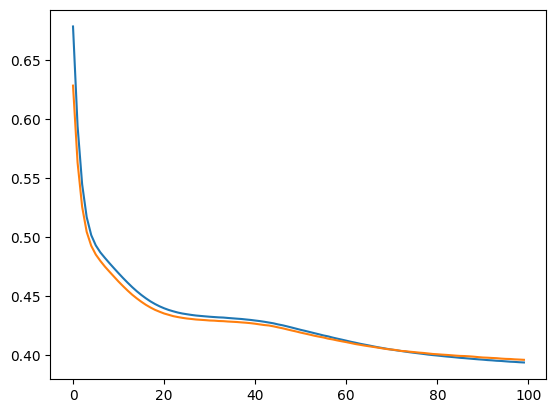

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

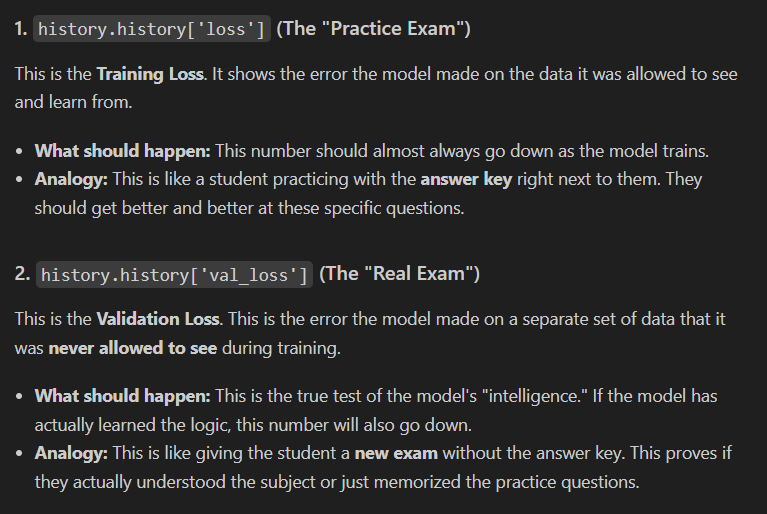

The moment you see the loss and val_loss start to pull away from each other (where the gap gets wider), that is the exact moment your model stopped "learning" and started "memorizing."

In Churn Prediction, this graph is vital. If your val_loss is much higher than your loss, your model might tell you it's 99% accurate, but it will fail completely when you give it real customers next month!

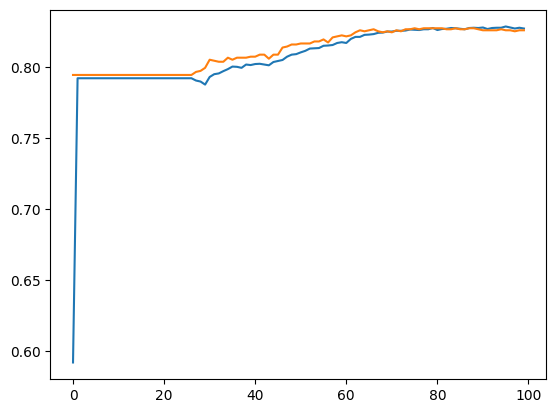

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Explaining Graphs

After training your model, you typically plot two sets of graphs: **Loss** and **Accuracy**. Here is how to read them.



### 1. Accuracy: The "Report Card"
Accuracy measures the percentage of correct predictions.

*   **Training Accuracy:** How well the model performs on the data it is learning from.
*   **Validation Accuracy:** How well the model performs on "hidden" data it has never seen.
*   **What to look for:** You want these lines to go **UP**.
*   **The Goal:** Both lines should be high and close to each other.



### 2. Loss: The "Error Score"
Loss measures the mathematical distance between the model's prediction and the true answer.

*   **Training Loss:** The error the model makes during its learning phase.
*   **Validation Loss:** The error the model makes when tested on new data.
*   **What to look for:** You want these lines to go **DOWN**.
*   **The Goal:** Both lines should reach a low point and stay there.



### 3. Comparing Training vs. Validation
The relationship between these two lines tells you if your model is actually learning or just memorizing.

| Observation | Meaning | Analogy |
| :--- | :--- | :--- |
| **Lines are close together** | **Healthy Learning** | The student understood the logic and passed the real exam. |
| **Big Gap (Training better than Val)** | **Overfitting** | The student memorized the practice answers but failed the real exam. |
| **Both lines are poor** | **Underfitting** | The student didn't study enough or the material was too hard. |



### Quick Cheat Sheet
*   **High Accuracy + Low Loss:** The perfect model.
*   **High Accuracy + High Loss:** The model is guessing right, but it's not "confident" (the math is still messy).
*   **Low Accuracy + Low Loss:** Rare. Usually means there is a bug in your metrics or your data is too simple.
